In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- Input files  ----------
meta_file = "Chalasani_ALT_AST.csv"
sra_map_file = "PRJNA701722_SraRunTable.csv"

# ---------- Load SRA → Sample mapping ----------
sra_map = pd.read_csv(sra_map_file, usecols=["Run", "Sample Name"])
sra_map = sra_map.rename(columns={"Run": "SRR", "Sample Name": "SAMPLE ID"})

# ---------- Load ALT/AST metadata ----------
meta = pd.read_csv(meta_file)
meta = meta.rename(columns={"SAMLPE ID": "SAMPLE ID"})  # fix typo if present

# ---------- Harmonise sample IDs ----------
sra_map["SAMPLE_clean"] = sra_map["SAMPLE ID"].astype(str).str.extract(r"(\d+)")[0]
meta["SAMPLE_clean"] = meta["SAMPLE ID"].astype(str).str.extract(r"(\d+)")[0]

sra_map = sra_map.dropna(subset=["SAMPLE_clean"])
meta = meta.dropna(subset=["SAMPLE_clean"])

# ---------- Merge SRR → ALT / AST ----------
merged = pd.merge(sra_map, meta, on="SAMPLE_clean", how="inner")

print(f"Merged samples with ALT/AST metadata: {merged.shape[0]}")

# ---------- Prepare ALT / AST ----------
merged["ALT"] = pd.to_numeric(merged["ALT"], errors="coerce")
merged["AST"] = pd.to_numeric(merged["AST"], errors="coerce")

# ---------- Plot ----------
sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

sns.histplot(
    merged["ALT"].dropna(),
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("ALT distribution")
axes[0].set_xlabel("ALT (U/L)")
axes[0].set_ylabel("Count")

sns.histplot(
    merged["AST"].dropna(),
    bins=30,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("AST distribution")
axes[1].set_xlabel("AST (U/L)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


In [2]:
import pandas as pd
import numpy as np

files = {
    "Healthy": "TOO-Decon-Published/Chalasani_Fatty-Liver/Decon-Results_Chalasani_Healthy/merged_normalised_results.txt",
    "NAFLD":   "TOO-Decon-Published/Chalasani_Fatty-Liver/Decon-Results_Chalasani_NAFLD/merged_normalised_results.txt",
    "NASH":    "TOO-Decon-Published/Chalasani_Fatty-Liver/Decon-Results_Chalasani_NASH/merged_normalised_results.txt"
}

dfs = []
for cohort, path in files.items():
    df = pd.read_csv(path, sep="\t", index_col=0)
    df = df.reset_index().rename(columns={"index": "Sample"})
    df["Cohort"] = cohort
    dfs.append(df)

merged = pd.concat(dfs, ignore_index=True)

exclude_cols = ["Sample", "DeconvolutionTool", "Cohort"]
Tissue_cols = [c for c in merged.columns if c not in exclude_cols]

long_df = merged.melt(
    id_vars=["Sample", "DeconvolutionTool", "Cohort"],
    value_vars=Tissue_cols,
    var_name="Tissue",
    value_name="Contribution"
)

long_df["Contribution"] = pd.to_numeric(long_df["Contribution"], errors="coerce")
long_df = long_df.dropna(subset=["Contribution"])


/tmp/ipykernel_3636085/2823228246.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = df_tool.groupby("Cohort_group")["Contribution"].apply(list)


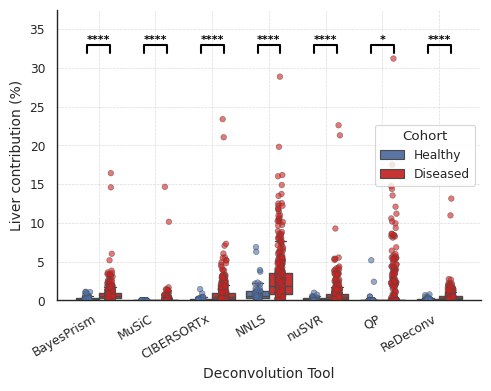

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans']

def pval_to_star(p):
    if p < 0.0001: return "****"
    elif p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# ---------- Healthy vs Diseased (NAFLD + NASH) ----------
long_df["Cohort_group"] = np.where(long_df["Cohort"].eq("Healthy"), "Healthy", "Diseased")
long_df["Cohort_group"] = pd.Categorical(long_df["Cohort_group"],
                                        categories=["Healthy", "Diseased"], ordered=True)

# ---------- Filter Liver ----------
liver_df = long_df[long_df["Tissue"].str.lower().str.contains("liver")].copy()
if liver_df.empty:
    raise ValueError("No 'Liver' tissue column found in deconvolution results.")

# ---------- Stats per tool: Healthy vs Diseased ----------
liver_stats = []
for tool, df_tool in liver_df.groupby("DeconvolutionTool"):
    groups = df_tool.groupby("Cohort_group")["Contribution"].apply(list)

    if "Healthy" in groups and "Diseased" in groups and len(groups["Healthy"]) and len(groups["Diseased"]):
        stat, pval = mannwhitneyu(groups["Healthy"], groups["Diseased"], alternative="two-sided")
        liver_stats.append({"DeconvolutionTool": tool, "pval": pval})

liver_stats_df = pd.DataFrame(liver_stats)
if liver_stats_df.empty:
    raise ValueError("No valid Healthy vs Diseased comparisons were possible (check sample overlap).")

# BH correction across tools (for the plotted comparisons)
#reject, pvals_corrected, _, _ = multipletests(liver_stats_df["pval"], method="fdr_bh")
#liver_stats_df["BH_adj_p"] = pvals_corrected
#liver_stats_df["Stars"] = [pval_to_star(p) for p in liver_stats_df["BH_adj_p"]]

# Stars are based on raw p-values per tool (descriptive method comparison).
liver_stats_df["Stars"] = [pval_to_star(p) for p in liver_stats_df["pval"]]

# ---------- Plot ----------
palette = {"Healthy": "#4C72B0", "Diseased": "#DD1C1A"}

plt.figure(figsize=(5, 4))
sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.0)

ax = sns.boxplot(
    data=liver_df,
    x="DeconvolutionTool",
    y="Contribution",
    hue="Cohort_group",
    palette=palette,
    dodge=True,
    showfliers=False
)

sns.stripplot(
    data=liver_df,
    x="DeconvolutionTool",
    y="Contribution",
    hue="Cohort_group",
    palette=palette,
    dodge=True,
    jitter=True,
    alpha=0.6,
    linewidth=0.5,
    size=4
)

# Remove duplicate legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Cohort")

# Annotate stars from raw p-values (no BH correction)
xticks = ax.get_xticks()
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
tool_to_x = dict(zip(xticklabels, xticks))

def add_bracket(ax, x1, x2, y, text, height):
    ax.plot([x1, x1, x2, x2], [y, y+height, y+height, y], lw=1.5, c="black")
    ax.text((x1+x2)/2, y+height, text, ha="center", va="bottom",
            fontsize=8, fontweight="bold", color="black")

# ---------- Fixed y-limit (same as before) ----------
ymax_plot = 37.5
ax.set_ylim(0, ymax_plot)

# Position brackets safely within the fixed limit
y = ymax_plot * 0.85
height = ymax_plot * 0.03

for _, row in liver_stats_df.iterrows():
    tool = row["DeconvolutionTool"]
    if tool in tool_to_x:
        x = tool_to_x[tool]
        add_bracket(ax, x - 0.2, x + 0.2, y, row["Stars"], height)

ax.set_xlabel("Deconvolution Tool", fontsize=10)
ax.set_ylabel("Liver contribution (%)", fontsize=10)
#ax.set_title("Liver contribution: Healthy vs Diseased (NAFLD+NASH) across tools",
#             fontsize=16, fontweight="bold")
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.savefig("Healthy_vs_Diseased_Chalasani_Liver.svg", format="svg", bbox_inches="tight")
plt.show()
